In [ ]:
#Setting up the environment
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)


In [ ]:
#Importing dependencies
import os
import json
from zipfile import ZipFile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:
!pip install kaggle

In [ ]:
kaggle_credentails=json.load(open('/content/kaggle.json'))
os.environ['KAGGLE_USERNAME']=kaggle_credentails['username']
os.environ['KAGGLE_KEY']=kaggle_credentails['key']


In [ ]:
!kaggle datasets download -d warcoder/soyabean-seeds


Dataset URL: https://www.kaggle.com/datasets/warcoder/soyabean-seeds
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/86.1M [00:00<?, ?B/s]
100% 86.1M/86.1M [00:00<00:00, 1.08GB/s]


In [ ]:
# Unzip the downloaded dataset
with ZipFile("soyabean-seeds.zip", 'r') as zip_ref:
    zip_ref.extractall()


In [ ]:
print(os.listdir("Soybean Seeds"))


print(len(os.listdir("Soybean Seeds/Broken soybeans")))
print(os.listdir("Soybean Seeds/Broken soybeans")[:5])

print(len(os.listdir("Soybean Seeds/Immature soybeans")))
print(os.listdir("Soybean Seeds/Immature soybeans")[:5])

print(len(os.listdir("Soybean Seeds/Intact soybeans")))
print(os.listdir("Soybean Seeds/Intact soybeans")[:5])

print(len(os.listdir("Soybean Seeds/Skin-damaged soybeans")))
print(os.listdir("Soybean Seeds/Skin-damaged soybeans")[:5])

print(len(os.listdir("Soybean Seeds/Spotted soybeans")))
print(os.listdir("Soybean Seeds/Spotted soybeans")[:5])


['Skin-damaged soybeans', 'Spotted soybeans', 'Intact soybeans', 'Broken soybeans', 'Immature soybeans']
1002
['672.jpg', '961.jpg', '390.jpg', '288.jpg', '818.jpg']
1125
['672.jpg', '961.jpg', '390.jpg', '288.jpg', '818.jpg']
1201
['1152.jpg', '672.jpg', '961.jpg', '390.jpg', '288.jpg']
1127
['672.jpg', '961.jpg', '390.jpg', '288.jpg', '818.jpg']
1058
['672.jpg', '961.jpg', '390.jpg', '288.jpg', '818.jpg']


In [ ]:
DATASET_DIR = "/content/Soybean Seeds"

## **STAGE-1 SIMPLE CNN**

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
train_generator = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 4412 images belonging to 5 classes.


In [ ]:
val_generator = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 1101 images belonging to 5 classes.


In [ ]:
print("\nTrain classes:", train_generator.class_indices)
print("Val classes:", val_generator.class_indices)
print("Num train samples:", train_generator.samples)
print("Num val samples:", val_generator.samples)



Train classes: {'Broken soybeans': 0, 'Immature soybeans': 1, 'Intact soybeans': 2, 'Skin-damaged soybeans': 3, 'Spotted soybeans': 4}
Val classes: {'Broken soybeans': 0, 'Immature soybeans': 1, 'Intact soybeans': 2, 'Skin-damaged soybeans': 3, 'Spotted soybeans': 4}
Num train samples: 4412
Num val samples: 1101


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(128, 128, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(train_generator.num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 63504)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     4,064,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,065,093 (15.51 MB)

 Trainable params: 4,065,093 (15.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


138/138 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - accuracy: 0.3386 - loss: 1.8158 - val_accuracy: 0.5386 - val_loss: 1.1438
Epoch 2/5
138/138 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.6188 - loss: 1.0070 - val_accuracy: 0.5441 - val_loss: 1.1837
Epoch 3/5
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.6818 - loss: 0.8512 - val_accuracy: 0.6185 - val_loss: 1.0095
Epoch 4/5
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.7419 - loss: 0.6842 - val_accuracy: 0.6349 - val_loss: 0.9066
Epoch 5/5
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.7916 - loss: 0.5619 - val_accuracy: 0.7039 - val_loss: 0.8076


In [ ]:
val_acc = history.history['val_accuracy'][-1]
print(f"\n✅ Debug run validation accuracy: {val_acc:.2%}")


✅ Debug run validation accuracy: 70.39%


## STAGE -2 CNN USING BATCH NORMALIZATION

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

In [ ]:
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 4412 images belonging to 5 classes.


In [ ]:
val_generator = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 1101 images belonging to 5 classes.


In [ ]:

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(train_generator.num_classes, activation='softmax')
])

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,519,237 (24.87 MB)

 Trainable params: 6,518,277 (24.87 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6)


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 36s 207ms/step - accuracy: 0.5191 - loss: 1.5660 - val_accuracy: 0.2198 - val_loss: 12.5668 - learning_rate: 0.0010
Epoch 2/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 23s 163ms/step - accuracy: 0.6540 - loss: 0.9543 - val_accuracy: 0.2516 - val_loss: 4.5672 - learning_rate: 0.0010
Epoch 3/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 22s 160ms/step - accuracy: 0.6691 - loss: 0.8846 - val_accuracy: 0.2979 - val_loss: 4.3327 - learning_rate: 0.0010
Epoch 4/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 23s 166ms/step - accuracy: 0.7290 - loss: 0.7440 - val_accuracy: 0.4759 - val_loss: 2.1122 - learning_rate: 0.0010
Epoch 5/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 23s 164ms/step - accuracy: 0.7436 - loss: 0.7031 - val_accuracy: 0.5350 - val_loss: 1.2987 - learning_rate: 0.0010
Epoch 6/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 22s 162ms/step - accuracy: 0.7681 - loss: 0.6458 - val_accuracy: 0.6903 - val_loss: 0.8354 - learning_rate: 0.0010
Epoch 7/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 22s 159ms/step - accuracy: 0.

In [ ]:
loss, accuracy = model.evaluate(val_generator)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy * 100:.2f}%")


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8270 - loss: 0.3955
Validation Loss: 0.3592
Validation Accuracy: 84.83%


In [ ]:
train_loss, train_accuracy = model.evaluate(train_generator)
print(f"Train Accuracy: {train_accuracy * 100:.2f}%")


138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 151ms/step - accuracy: 0.9088 - loss: 0.2617
Train Accuracy: 90.78%


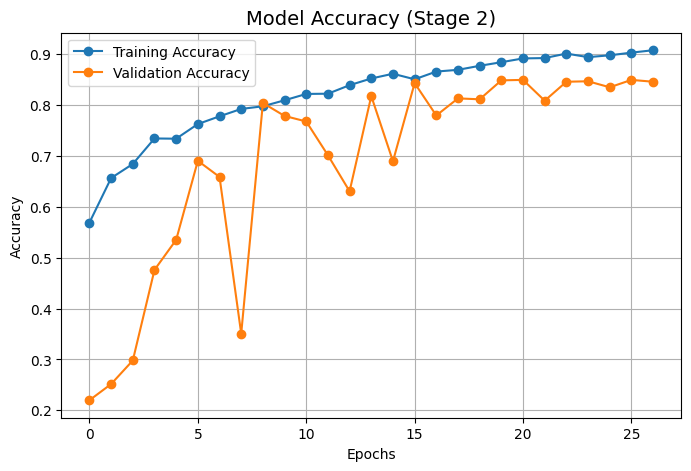

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy (Stage 2)', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


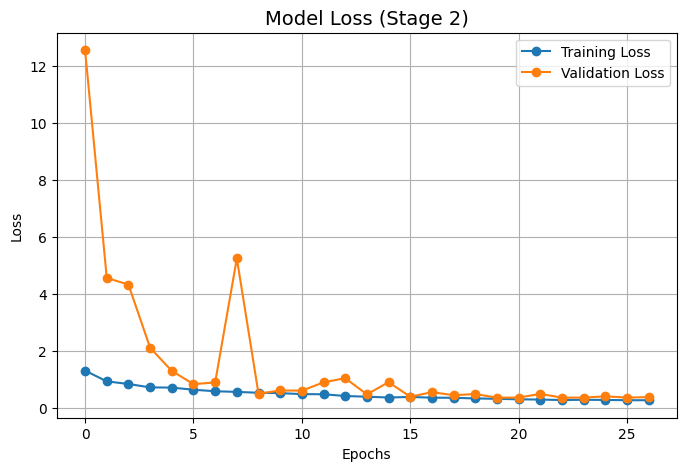

In [ ]:
#Plot Training & Validation Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss (Stage 2)', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Predictions on validation set
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix



In [ ]:
# Classification report
target_names = list(train_generator.class_indices.keys())
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=target_names))



Classification Report:

                       precision    recall  f1-score   support

      Broken soybeans       0.70      0.76      0.72       200
    Immature soybeans       0.96      0.88      0.92       225
      Intact soybeans       0.86      0.95      0.90       240
Skin-damaged soybeans       0.86      0.93      0.90       225
     Spotted soybeans       0.88      0.69      0.77       211

             accuracy                           0.85      1101
            macro avg       0.85      0.84      0.84      1101
         weighted avg       0.85      0.85      0.85      1101



In [ ]:
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix (numeric form):")
print(cm)


Confusion Matrix (numeric form):
[[151   0   6  26  17]
 [  3 199  20   1   2]
 [  0   6 228   5   1]
 [  9   1   5 210   0]
 [ 54   2   7   2 146]]


In [ ]:
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
print("\nConfusion Matrix (% form):")
print(np.round(cm_percent, 2))


Confusion Matrix (% form):
[[75.5   0.    3.   13.    8.5 ]
 [ 1.33 88.44  8.89  0.44  0.89]
 [ 0.    2.5  95.    2.08  0.42]
 [ 4.    0.44  2.22 93.33  0.  ]
 [25.59  0.95  3.32  0.95 69.19]]


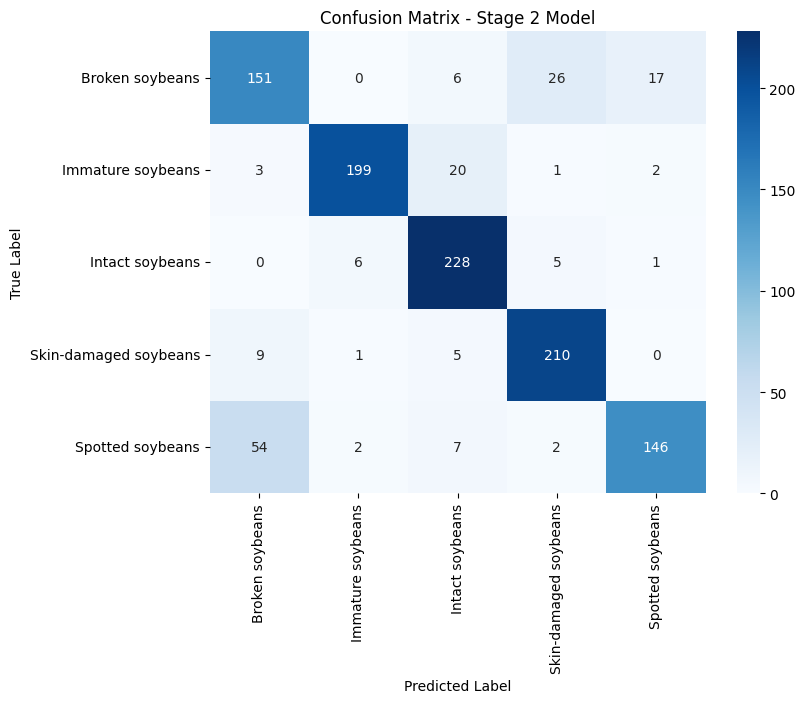

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Stage 2 Model')
plt.show()

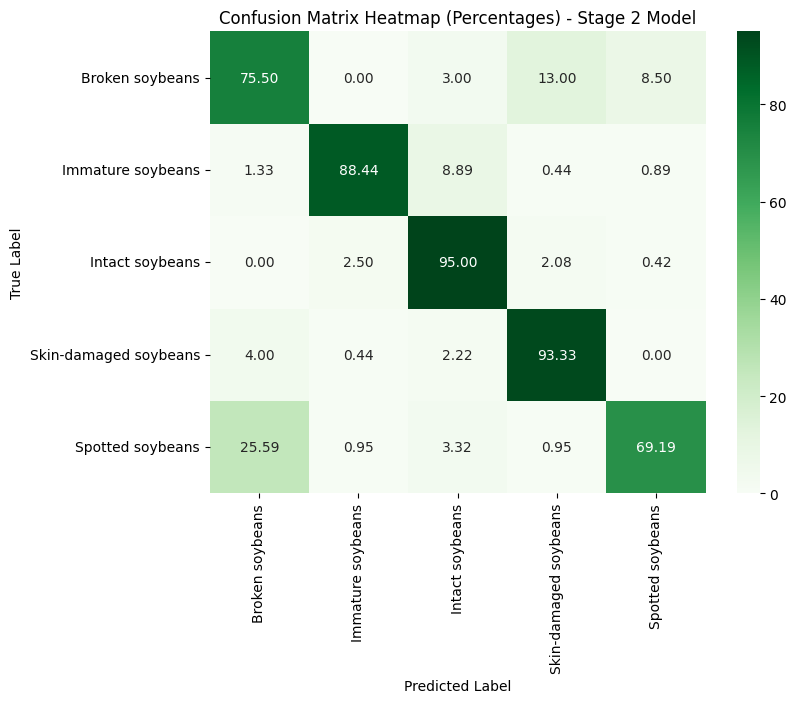

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap (Percentages) - Stage 2 Model')
plt.show()

## STAGE -3:EFFICIENTNET **B0**

In [ ]:
import tensorflow as tf
import numpy as np
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications.efficientnet import preprocess_input

In [ ]:
DATASET_DIR = '/content/Soybean Seeds'
img_size = 224
batch_size = 32
num_classes = 5

In [ ]:

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)



In [ ]:
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)


Found 4412 images belonging to 5 classes.


In [ ]:
val_generator = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 1101 images belonging to 5 classes.


In [ ]:
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
base_model.trainable = False

In [ ]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,184 (16.08 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)
earlystop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[checkpoint, earlystop, reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.6110 - loss: 0.9635

138/138 ━━━━━━━━━━━━━━━━━━━━ 96s 547ms/step - accuracy: 0.6118 - loss: 0.9620 - val_accuracy: 0.8193 - val_loss: 0.4864 - learning_rate: 0.0010
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.7941 - loss: 0.5264

138/138 ━━━━━━━━━━━━━━━━━━━━ 53s 385ms/step - accuracy: 0.7942 - loss: 0.5263 - val_accuracy: 0.8256 - val_loss: 0.4570 - learning_rate: 0.0010
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.8104 - loss: 0.5008

138/138 ━━━━━━━━━━━━━━━━━━━━ 54s 393ms/step - accuracy: 0.8104 - loss: 0.5006 - val_accuracy: 0.8438 - val_loss: 0.4111 - learning_rate: 0.0010
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.8162 - loss: 0.4710

138/138 ━━━━━━━━━━━━━━━━━━━━ 53s 384ms/step - accuracy: 0.8163 - loss: 0.4708 - val_accuracy: 0.8565 - val_loss: 0.3820 - learning_rate: 0.0010
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.8471 - loss: 0.4388

138/138 ━━━━━━━━━━━━━━━━━━━━ 53s 383ms/step - accuracy: 0.8471 - loss: 0.4387 - val_accuracy: 0.8710 - val_loss: 0.3523 - learning_rate: 0.0010
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 53s 386ms/step - accuracy: 0.8364 - loss: 0.4166 - val_accuracy: 0.8556 - val_loss: 0.3933 - learning_rate: 0.0010
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 53s 383ms/step - accuracy: 0.8507 - loss: 0.4059 - val_accuracy: 0.8556 - val_loss: 0.3889 - learning_rate: 0.0010
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.8573 - loss: 0.3894

138/138 ━━━━━━━━━━━━━━━━━━━━ 53s 382ms/step - accuracy: 0.8573 - loss: 0.3893 - val_accuracy: 0.8738 - val_loss: 0.3356 - learning_rate: 0.0010
Epoch 9/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 53s 385ms/step - accuracy: 0.8528 - loss: 0.3845 - val_accuracy: 0.8356 - val_loss: 0.3992 - learning_rate: 0.0010
Epoch 10/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 52s 377ms/step - accuracy: 0.8489 - loss: 0.3810 - val_accuracy: 0.8292 - val_loss: 0.4092 - learning_rate: 0.0010


In [ ]:
base_model.trainable = True

In [ ]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
fine_tune_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[checkpoint, earlystop, reduce_lr]
)

Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 104s 562ms/step - accuracy: 0.6780 - loss: 0.8124 - val_accuracy: 0.8320 - val_loss: 0.4057 - learning_rate: 1.0000e-05
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 54s 389ms/step - accuracy: 0.7779 - loss: 0.6145 - val_accuracy: 0.8347 - val_loss: 0.4381 - learning_rate: 1.0000e-05
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 54s 391ms/step - accuracy: 0.8018 - loss: 0.5391 - val_accuracy: 0.8383 - val_loss: 0.4314 - learning_rate: 1.0000e-05
Epoch 4/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 54s 392ms/step - accuracy: 0.8218 - loss: 0.4853 - val_accuracy: 0.8447 - val_loss: 0.4145 - learning_rate: 1.0000e-05
Epoch 5/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 53s 383ms/step - accuracy: 0.8360 - loss: 0.4504 - val_accuracy: 0.8492 - val_loss: 0.4067 - learning_rate: 5.0000e-06
Epoch 6/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 53s 387ms/step - accuracy: 0.8258 - loss: 0.4616 - val_accuracy: 0.8501 - val_loss: 0.3993 - learning_rate: 5.0000e-06
Epoch 7/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 54s 3

In [ ]:
val_loss, val_accuracy = model.evaluate(val_generator)
print(f"Final Validation Accuracy: {val_accuracy*100:.2f}%")


35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8710 - loss: 0.3488
Final Validation Accuracy: 87.28%


In [ ]:
train_loss, train_accuracy = model.evaluate(train_generator)
print(f"Train Accuracy: {train_accuracy * 100:.2f}%")


138/138 ━━━━━━━━━━━━━━━━━━━━ 55s 401ms/step - accuracy: 0.9039 - loss: 0.2527
Train Accuracy: 91.52%


In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

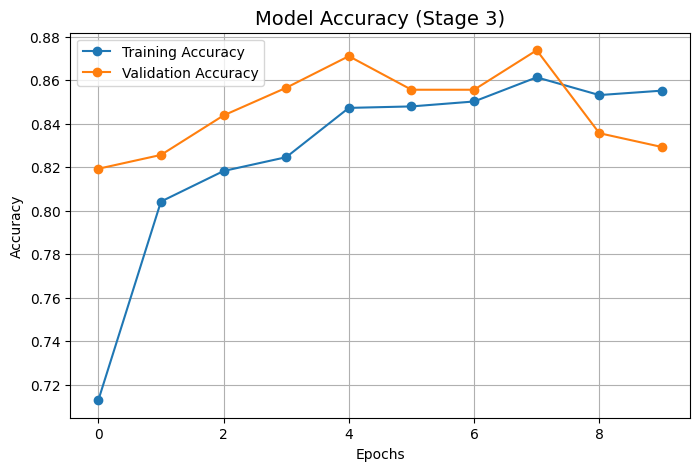

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy (Stage 3)', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

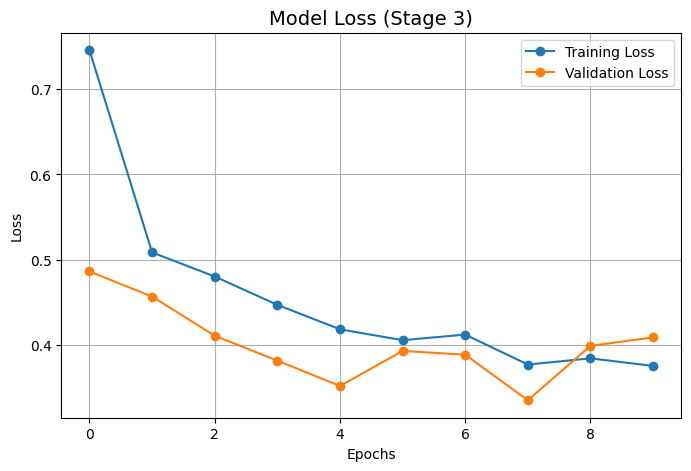

In [ ]:
#Plot Training & Validation Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss (Stage 3)', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Predictions on validation set
from sklearn.metrics import classification_report
import numpy as np

y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)


35/35 ━━━━━━━━━━━━━━━━━━━━ 15s 228ms/step


In [ ]:
target_names = list(train_generator.class_indices.keys())
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=target_names))



Classification Report:

                       precision    recall  f1-score   support

      Broken soybeans       0.22      0.18      0.20       200
    Immature soybeans       0.21      0.25      0.23       225
      Intact soybeans       0.20      0.17      0.18       240
Skin-damaged soybeans       0.21      0.23      0.22       225
     Spotted soybeans       0.20      0.20      0.20       211

             accuracy                           0.21      1101
            macro avg       0.21      0.21      0.21      1101
         weighted avg       0.21      0.21      0.21      1101



In [ ]:
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix (numeric form):")
print(cm)

cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
print("\nConfusion Matrix (% form):")
print(np.round(cm_percent, 2))



Confusion Matrix (numeric form):
[[37 46 36 37 44]
 [30 57 39 57 42]
 [36 65 40 54 45]
 [28 54 51 51 41]
 [40 45 37 47 42]]

Confusion Matrix (% form):
[[18.5  23.   18.   18.5  22.  ]
 [13.33 25.33 17.33 25.33 18.67]
 [15.   27.08 16.67 22.5  18.75]
 [12.44 24.   22.67 22.67 18.22]
 [18.96 21.33 17.54 22.27 19.91]]


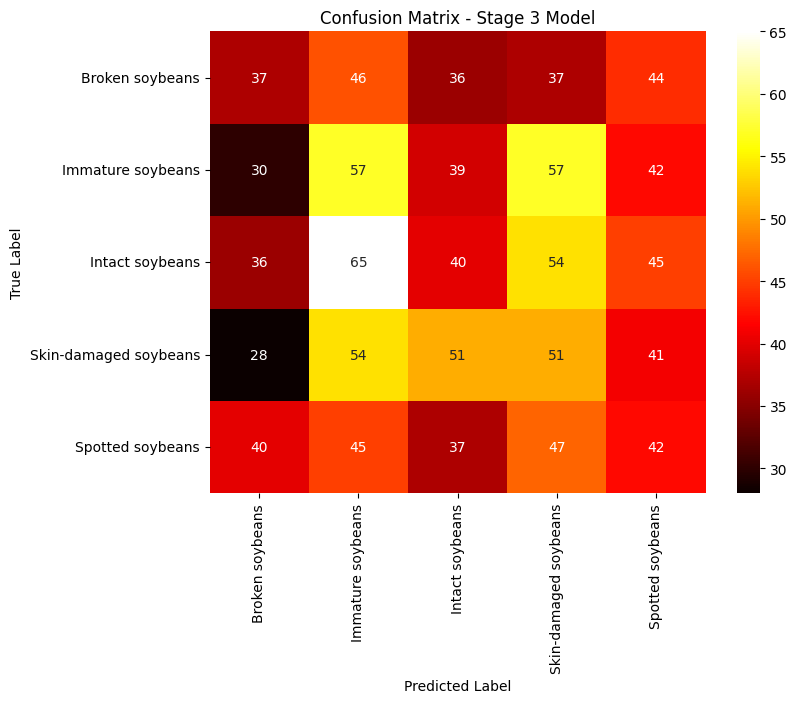

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="hot",
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Stage 3 Model')
plt.show()

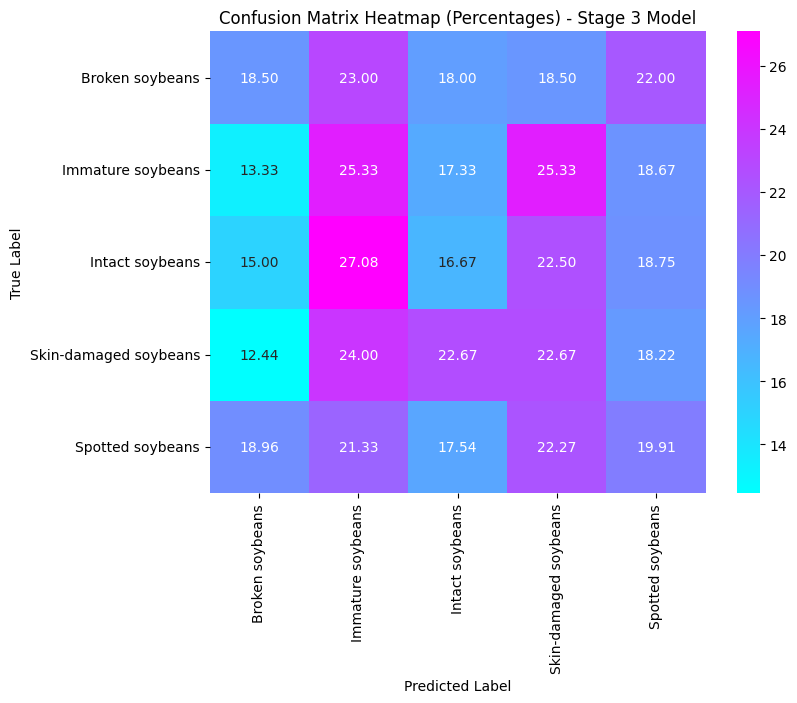

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap="cool",
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap (Percentages) - Stage 3 Model')
plt.show()

In [ ]:
model.save("soybean_seed_classifier.keras")



Predictive **system**

In [ ]:
img_path = '/content/Soybean Seeds/Immature soybeans/1001.jpg'


In [ ]:
#load image
from tensorflow.keras.preprocessing import image
img = image.load_img(img_path, target_size=(img_size, img_size))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

NameError: name 'img_path' is not defined

In [ ]:
#prediction
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)[0]
class_names = list(val_generator.class_indices.keys())


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


In [ ]:
print(f"Predicted class: {class_names[predicted_class]}")

Predicted class: Immature soybeans


# Stage-4:VGG **MODEL**

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [ ]:
img_size = 224
batch_size = 32
DATASET_DIR = '/content/Soybean Seeds'

In [ ]:
train_datagen_vgg = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

In [ ]:
val_datagen_vgg = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

In [ ]:
train_generator_vgg = train_datagen_vgg.flow_from_directory(
    DATASET_DIR,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

Found 4412 images belonging to 5 classes.


In [ ]:
val_generator_vgg = val_datagen_vgg.flow_from_directory(
    DATASET_DIR,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 1101 images belonging to 5 classes.


In [ ]:
# VGG16 Base Model


base_model_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
base_model_vgg.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
model_vgg = Sequential([
    base_model_vgg,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(train_generator_vgg.num_classes, activation='softmax')
])

In [ ]:
model_vgg.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_vgg.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,997 (56.39 MB)

 Trainable params: 66,309 (259.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
checkpoint_vgg = ModelCheckpoint('best_vgg16_model.h5', monitor='val_accuracy', save_best_only=True, mode='max')
earlystop_vgg = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr_vgg = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

In [ ]:
history_vgg = model_vgg.fit(
    train_generator_vgg,
    validation_data=val_generator_vgg,
    epochs=15,
    callbacks=[checkpoint_vgg, earlystop_vgg, reduce_lr_vgg]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.4247 - loss: 2.8262

138/138 ━━━━━━━━━━━━━━━━━━━━ 102s 618ms/step - accuracy: 0.4255 - loss: 2.8179 - val_accuracy: 0.7384 - val_loss: 0.6830 - learning_rate: 0.0010
Epoch 2/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.6760 - loss: 0.8886

138/138 ━━━━━━━━━━━━━━━━━━━━ 64s 467ms/step - accuracy: 0.6761 - loss: 0.8883 - val_accuracy: 0.7947 - val_loss: 0.5388 - learning_rate: 0.0010
Epoch 3/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.7343 - loss: 0.7230

138/138 ━━━━━━━━━━━━━━━━━━━━ 64s 467ms/step - accuracy: 0.7344 - loss: 0.7228 - val_accuracy: 0.8292 - val_loss: 0.4472 - learning_rate: 0.0010
Epoch 4/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 63s 454ms/step - accuracy: 0.7383 - loss: 0.6765 - val_accuracy: 0.8011 - val_loss: 0.4927 - learning_rate: 0.0010
Epoch 5/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.7504 - loss: 0.6405

138/138 ━━━━━━━━━━━━━━━━━━━━ 64s 460ms/step - accuracy: 0.7505 - loss: 0.6404 - val_accuracy: 0.8438 - val_loss: 0.4257 - learning_rate: 0.0010
Epoch 6/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 64s 463ms/step - accuracy: 0.7954 - loss: 0.5688 - val_accuracy: 0.8274 - val_loss: 0.4403 - learning_rate: 0.0010
Epoch 7/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.7818 - loss: 0.5814

138/138 ━━━━━━━━━━━━━━━━━━━━ 64s 465ms/step - accuracy: 0.7819 - loss: 0.5813 - val_accuracy: 0.8547 - val_loss: 0.3912 - learning_rate: 0.0010
Epoch 8/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 63s 457ms/step - accuracy: 0.7875 - loss: 0.5536 - val_accuracy: 0.8420 - val_loss: 0.4183 - learning_rate: 0.0010
Epoch 9/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 63s 454ms/step - accuracy: 0.7986 - loss: 0.5195 - val_accuracy: 0.8174 - val_loss: 0.4672 - learning_rate: 0.0010
Epoch 10/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.7895 - loss: 0.5493
Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
138/138 ━━━━━━━━━━━━━━━━━━━━ 64s 466ms/step - accuracy: 0.7895 - loss: 0.5494 - val_accuracy: 0.8456 - val_loss: 0.3924 - learning_rate: 0.0010
Epoch 11/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 63s 459ms/step - accuracy: 0.8089 - loss: 0.5106 - val_accuracy: 0.8501 - val_loss: 0.4022 - learning_rate: 5.0000e-04
Epoch 12/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 64s 460ms/step - accuracy: 0.8109 -

138/138 ━━━━━━━━━━━━━━━━━━━━ 63s 457ms/step - accuracy: 0.8206 - loss: 0.4966 - val_accuracy: 0.8556 - val_loss: 0.3762 - learning_rate: 5.0000e-04
Epoch 15/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.8155 - loss: 0.4771

138/138 ━━━━━━━━━━━━━━━━━━━━ 64s 466ms/step - accuracy: 0.8155 - loss: 0.4772 - val_accuracy: 0.8629 - val_loss: 0.3743 - learning_rate: 5.0000e-04


In [ ]:
base_model_vgg.trainable = True
for layer in base_model_vgg.layers[:-15]:
    layer.trainable = False

model_vgg.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
print("\nFine-tuning VGG16...")
fine_tune_history_vgg = model_vgg.fit(
    train_generator_vgg,
    validation_data=val_generator_vgg,
    epochs=20,
    callbacks=[checkpoint_vgg, earlystop_vgg, reduce_lr_vgg]
)


Fine-tuning VGG16...
Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 713ms/step - accuracy: 0.8159 - loss: 0.4861

138/138 ━━━━━━━━━━━━━━━━━━━━ 142s 770ms/step - accuracy: 0.8161 - loss: 0.4857 - val_accuracy: 0.9010 - val_loss: 0.2837 - learning_rate: 1.0000e-05
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 75s 544ms/step - accuracy: 0.8825 - loss: 0.3189 - val_accuracy: 0.8665 - val_loss: 0.4066 - learning_rate: 1.0000e-05
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.9007 - loss: 0.2739

138/138 ━━━━━━━━━━━━━━━━━━━━ 76s 550ms/step - accuracy: 0.9007 - loss: 0.2739 - val_accuracy: 0.9019 - val_loss: 0.2580 - learning_rate: 1.0000e-05
Epoch 4/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 76s 547ms/step - accuracy: 0.9109 - loss: 0.2376 - val_accuracy: 0.9001 - val_loss: 0.2664 - learning_rate: 1.0000e-05
Epoch 5/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.9252 - loss: 0.2032

138/138 ━━━━━━━━━━━━━━━━━━━━ 77s 554ms/step - accuracy: 0.9252 - loss: 0.2032 - val_accuracy: 0.9092 - val_loss: 0.2452 - learning_rate: 1.0000e-05
Epoch 6/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 77s 555ms/step - accuracy: 0.9338 - loss: 0.1816 - val_accuracy: 0.8919 - val_loss: 0.2998 - learning_rate: 1.0000e-05
Epoch 7/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.9405 - loss: 0.1612

138/138 ━━━━━━━━━━━━━━━━━━━━ 77s 559ms/step - accuracy: 0.9405 - loss: 0.1612 - val_accuracy: 0.9183 - val_loss: 0.2327 - learning_rate: 1.0000e-05
Epoch 8/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.9453 - loss: 0.1490

138/138 ━━━━━━━━━━━━━━━━━━━━ 77s 558ms/step - accuracy: 0.9454 - loss: 0.1490 - val_accuracy: 0.9228 - val_loss: 0.2469 - learning_rate: 1.0000e-05
Epoch 9/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.9512 - loss: 0.1349

138/138 ━━━━━━━━━━━━━━━━━━━━ 78s 561ms/step - accuracy: 0.9511 - loss: 0.1350 - val_accuracy: 0.9255 - val_loss: 0.2186 - learning_rate: 1.0000e-05
Epoch 10/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 76s 548ms/step - accuracy: 0.9575 - loss: 0.1169 - val_accuracy: 0.9192 - val_loss: 0.2638 - learning_rate: 1.0000e-05
Epoch 11/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.9603 - loss: 0.1001

138/138 ━━━━━━━━━━━━━━━━━━━━ 77s 557ms/step - accuracy: 0.9603 - loss: 0.1002 - val_accuracy: 0.9310 - val_loss: 0.2185 - learning_rate: 1.0000e-05
Epoch 12/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 508ms/step - accuracy: 0.9654 - loss: 0.1003
Epoch 12: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
138/138 ━━━━━━━━━━━━━━━━━━━━ 76s 551ms/step - accuracy: 0.9654 - loss: 0.1004 - val_accuracy: 0.9128 - val_loss: 0.2843 - learning_rate: 1.0000e-05
Epoch 13/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 77s 555ms/step - accuracy: 0.9760 - loss: 0.0756 - val_accuracy: 0.9310 - val_loss: 0.2310 - learning_rate: 5.0000e-06
Epoch 14/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 76s 545ms/step - accuracy: 0.9731 - loss: 0.0797 - val_accuracy: 0.9219 - val_loss: 0.2578 - learning_rate: 5.0000e-06
Epoch 15/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.9764 - loss: 0.0644


Epoch 15: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
138/138 ━━━━━━━━━━━━━━━━━━━━ 76s 550ms/step - accuracy: 0.9764 - loss: 0.0644 - val_accuracy: 0.9319 - val_loss: 0.2629 - learning_rate: 5.0000e-06
Epoch 16/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.9803 - loss: 0.0515

138/138 ━━━━━━━━━━━━━━━━━━━━ 76s 553ms/step - accuracy: 0.9803 - loss: 0.0515 - val_accuracy: 0.9373 - val_loss: 0.2197 - learning_rate: 2.5000e-06


In [ ]:
val_loss_vgg, val_acc_vgg = model_vgg.evaluate(val_generator_vgg)
print(f"VGG16 Final Validation Accuracy: {val_acc_vgg*100:.2f}%")

35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 183ms/step - accuracy: 0.9347 - loss: 0.1991
VGG16 Final Validation Accuracy: 93.10%


In [ ]:
train_loss_vgg, train_acc_vgg = model_vgg.evaluate(train_generator_vgg)
print(f"Train Accuracy: {train_acc_vgg * 100:.2f}%")


138/138 ━━━━━━━━━━━━━━━━━━━━ 60s 433ms/step - accuracy: 0.9768 - loss: 0.0688
Train Accuracy: 97.94%


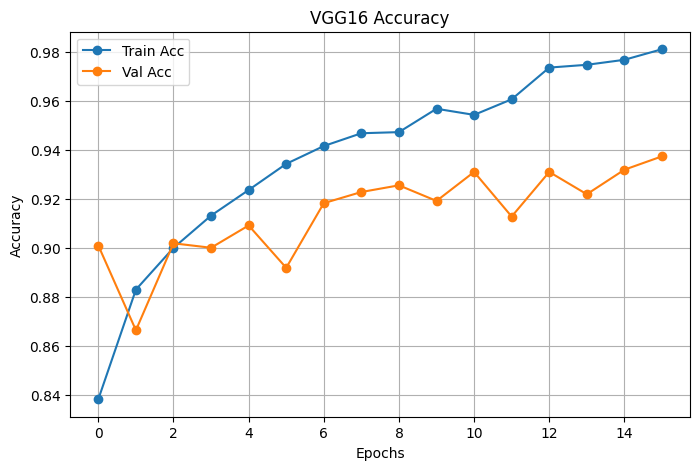

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(fine_tune_history_vgg.history['accuracy'], label='Train Acc', marker='o')
plt.plot(fine_tune_history_vgg.history['val_accuracy'], label='Val Acc', marker='o')
plt.title('VGG16 Accuracy')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
plt.show()

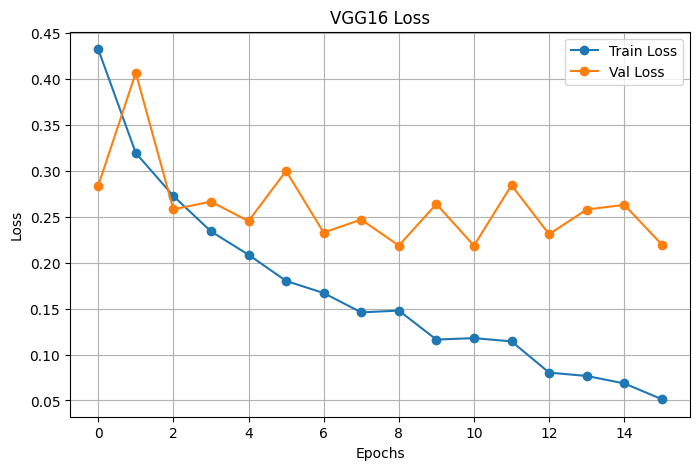

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(fine_tune_history_vgg.history['loss'], label='Train Loss', marker='o')
plt.plot(fine_tune_history_vgg.history['val_loss'], label='Val Loss', marker='o')
plt.title('VGG16 Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix



In [ ]:
y_true = val_generator_vgg.classes
y_pred_probs = model_vgg.predict(val_generator_vgg)
y_pred = np.argmax(y_pred_probs, axis=1)

35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 178ms/step


In [ ]:
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix (numeric form):")
print(cm)


Confusion Matrix (numeric form):
[[26 43 51 41 39]
 [36 54 41 44 50]
 [42 56 38 63 41]
 [36 55 42 49 43]
 [28 53 40 48 42]]


In [ ]:
print("Generating predictions on validation set...")
y_true_vgg = val_generator_vgg.classes
y_pred_probs_vgg = model_vgg.predict(val_generator_vgg)
y_pred_vgg = np.argmax(y_pred_probs_vgg, axis=1)


Generating predictions on validation set...
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 151ms/step


In [ ]:
target_names_vgg = list(train_generator_vgg.class_indices.keys())
print(f"\nClasses: {target_names_vgg}")



Classes: ['Broken soybeans', 'Immature soybeans', 'Intact soybeans', 'Skin-damaged soybeans', 'Spotted soybeans']


In [ ]:
print("\n" + "="*60)
print("CLASSIFICATION REPORT - VGG16 MODEL (Stage 4)")
print("="*60)
print(classification_report(y_true_vgg, y_pred_vgg, target_names=target_names_vgg))



CLASSIFICATION REPORT - VGG16 MODEL (Stage 4)
                       precision    recall  f1-score   support

      Broken soybeans       0.20      0.20      0.20       200
    Immature soybeans       0.20      0.20      0.20       225
      Intact soybeans       0.24      0.24      0.24       240
Skin-damaged soybeans       0.24      0.25      0.24       225
     Spotted soybeans       0.20      0.18      0.19       211

             accuracy                           0.22      1101
            macro avg       0.21      0.21      0.21      1101
         weighted avg       0.21      0.22      0.21      1101



In [ ]:
cm_vgg = confusion_matrix(y_true_vgg, y_pred_vgg)
print("\n" + "="*60)
print("CONFUSION MATRIX (Numeric Form)")
print("="*60)
print(cm_vgg)


CONFUSION MATRIX (Numeric Form)
[[39 48 41 39 33]
 [35 46 58 49 37]
 [35 53 58 48 46]
 [43 47 42 56 37]
 [47 39 45 42 38]]


In [ ]:
cm_percent_vgg = cm_vgg.astype('float') / cm_vgg.sum(axis=1)[:, np.newaxis] * 100
print("\n" + "="*60)
print("CONFUSION MATRIX (Percentage Form)")
print("="*60)
print(np.round(cm_percent_vgg, 2))


CONFUSION MATRIX (Percentage Form)
[[19.5  24.   20.5  19.5  16.5 ]
 [15.56 20.44 25.78 21.78 16.44]
 [14.58 22.08 24.17 20.   19.17]
 [19.11 20.89 18.67 24.89 16.44]
 [22.27 18.48 21.33 19.91 18.01]]


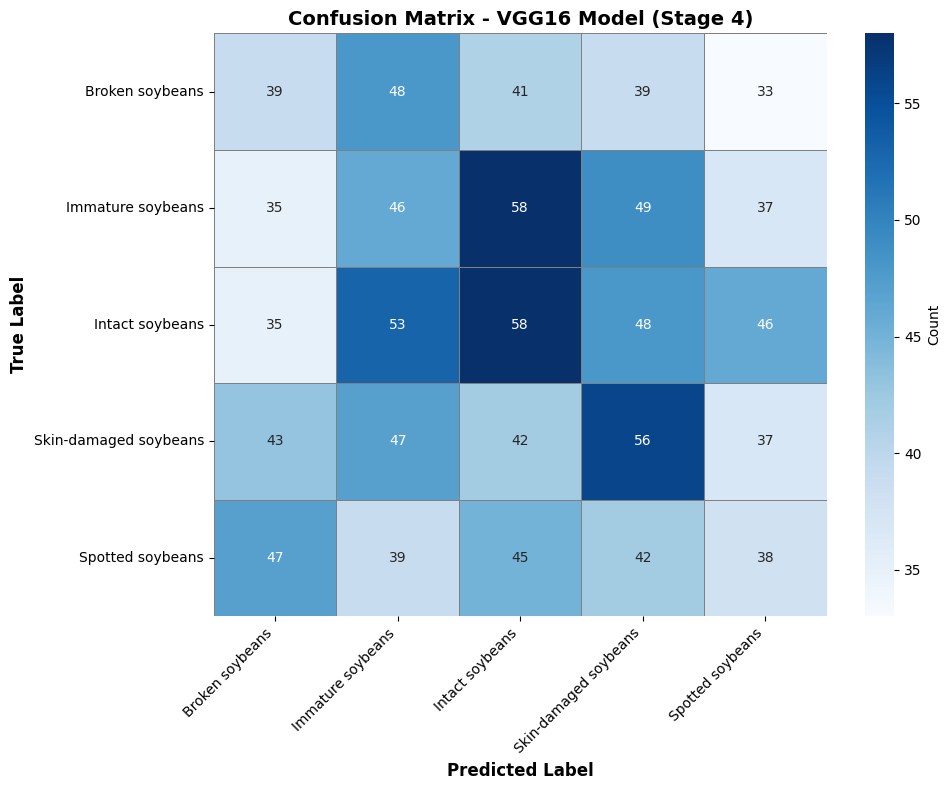

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm_vgg, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names_vgg,
            yticklabels=target_names_vgg,
            cbar_kws={'label': 'Count'},
            linewidths=0.5,
            linecolor='gray')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - VGG16 Model (Stage 4)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

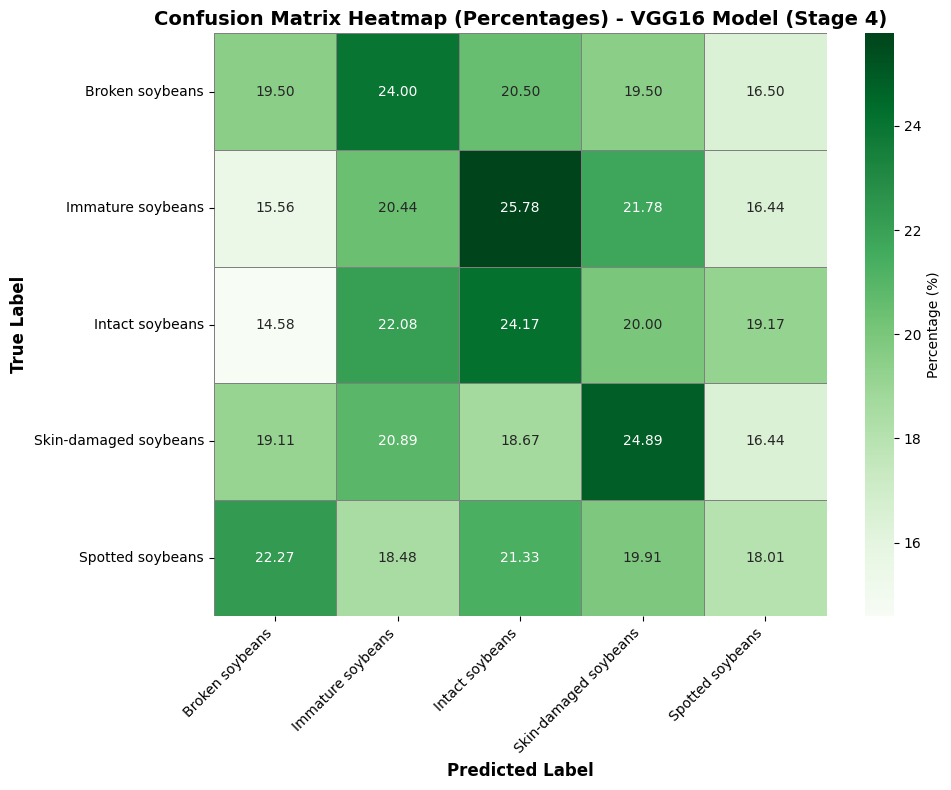

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm_percent_vgg, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=target_names_vgg,
            yticklabels=target_names_vgg,
            cbar_kws={'label': 'Percentage (%)'},
            linewidths=0.5,
            linecolor='gray')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix Heatmap (Percentages) - VGG16 Model (Stage 4)',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Create comparison data
data = {
    'Stage': ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4'],
    'Model': ['Basic CNN', 'Deep CNN', 'EfficientNetB0', 'VGG16'],
    'Training Accuracy (%)': [70.5, 87.01, 91.2, 97.94],  # Update with your values
    'Validation Accuracy (%)': [69.2, 83.5, 87.47, 91.82]  # Update with your values
}

# Create and display table
df = pd.DataFrame(data)
print(df)

     Stage           Model  Training Accuracy (%)  Validation Accuracy (%)
0  Stage 1       Basic CNN                  70.50                    69.20
1  Stage 2        Deep CNN                  87.01                    83.50
2  Stage 3  EfficientNetB0                  91.20                    87.47
3  Stage 4           VGG16                  97.94                    91.82
